# **Interactive Data Visualization with Plotly & Cufflinks**

Plotly is a powerful Python library that lets you create **interactive, publication-quality graphs** easily embeddable in websites or dashboards. It supports exporting visuals as HTML files or static images, making it incredibly versatile for data storytelling.

**Cufflinks** bridges the gap between Pandas and Plotly, enabling quick interactive plotting directly from DataFrames with simple syntax.


<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2009/Session%2009_3%20-%20Plotly%20and%20Cufflinks.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2009/Session%2009_3%20-%20Plotly%20and%20Cufflinks.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

---

## 📦 Installation

To get started, install Plotly and Cufflinks using pip:

```bash
pip install plotly
pip install cufflinks
```
---


## 🛠 Setup and Imports

In [1]:
!pip install plotly cufflinks

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for cufflinks: filename=cufflinks-0.17.3-py3-none-any.whl size=68721 sha256=b968d860fe5e565de30f78dafb497aebb2b7ba4ab970b22f00ef810e5589644b
  Stored in directory: c:\users\pc-gam\appdata\local\pip\cache\wheels\c0\d9\70\372130dacf508192607c1a7359c7bf0656b1a3b79f6cf66f7a
Successfully built cufflinks


In [2]:
import pandas as pd
import numpy as np

from plotly.offline import init_notebook_mode, iplot
import cufflinks as cf

# Enable notebook mode and offline plotting with cufflinks
init_notebook_mode(connected=True)
cf.go_offline()

### Fake Data

In [3]:
df = pd.DataFrame(np.random.randn(100, 4), columns=['A', 'B', 'C', 'D'])
df.head()

,A,B,C,D
0,1.045994,-1.394934,1.231118,-0.001189
1,0.688387,0.143124,0.566070,0.934617
2,-0.121892,-0.231212,-0.042491,0.758689
3,0.534086,-1.011378,1.085010,-1.572361
4,0.233261,0.892282,0.603816,0.817963


In [4]:
df2 = pd.DataFrame({'Category': ['A', 'B', 'C'], 'Values': [32, 43, 50]})
df2.head()

,Category,Values
0,A,32
1,B,43
2,C,50


## 📊 Basic Plot Types with Cufflinks

Cufflinks supports a wide range of plot types — here are some essentials:

* **scatter**
* **bar**
* **box**
* **spread**
* **heatmap**
* **surface**
* **histogram**
* **bubble**

### Scatter Plot

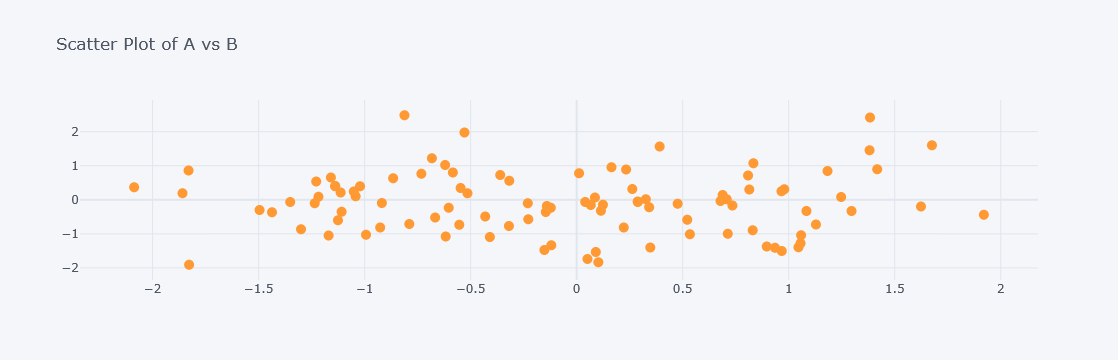

In [5]:
df.iplot(kind='scatter', x='A', y='B', mode='markers', size=10, title='Scatter Plot of A vs B')

### Bar Plot

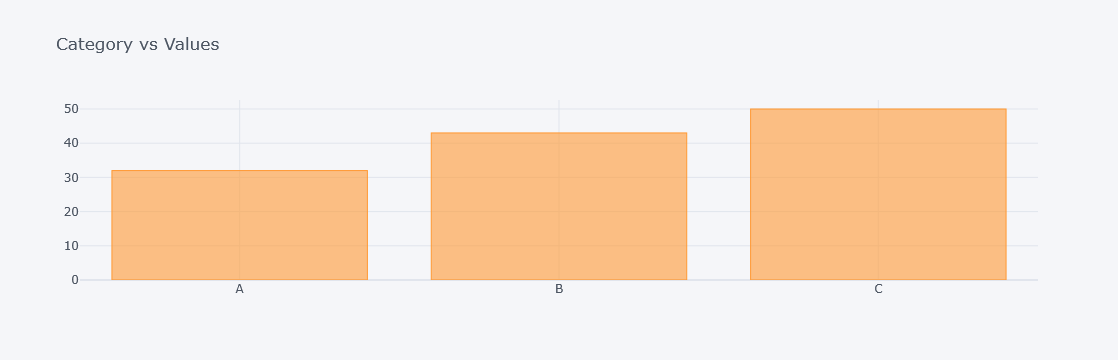

In [6]:
df2.iplot(kind='bar', x='Category', y='Values', title='Category vs Values')

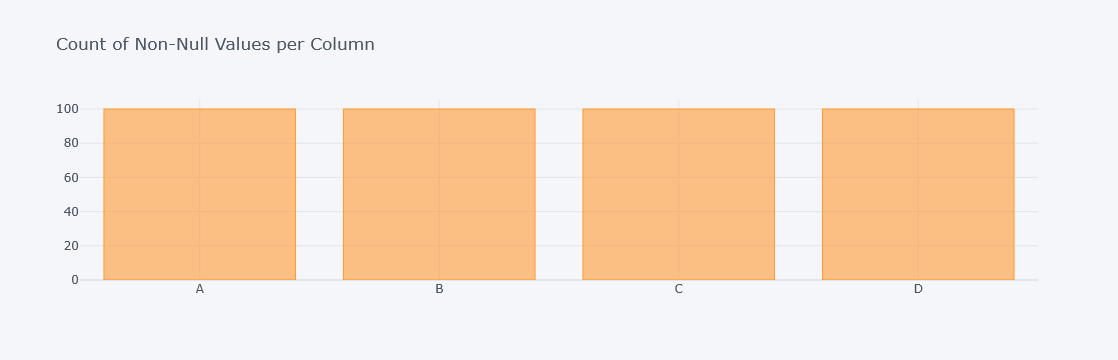

In [7]:
df.count().iplot(kind='bar', title='Count of Non-Null Values per Column')

### Boxplots

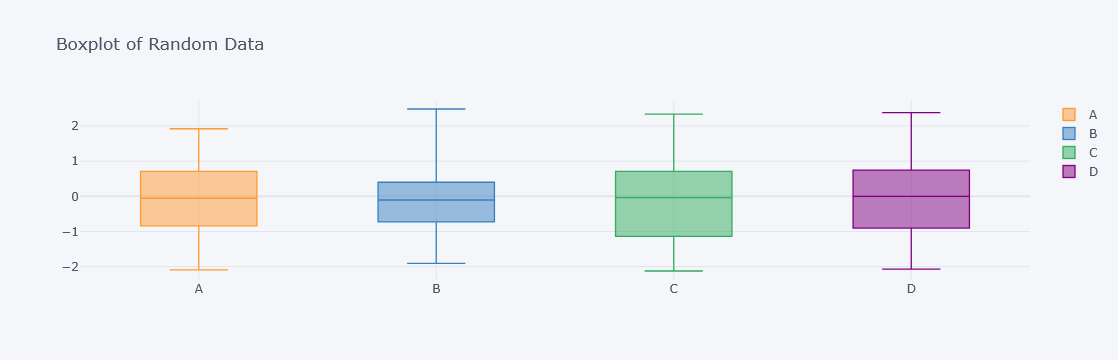

In [8]:
df.iplot(kind='box', title='Boxplot of Random Data')

### 3d Surface Plot

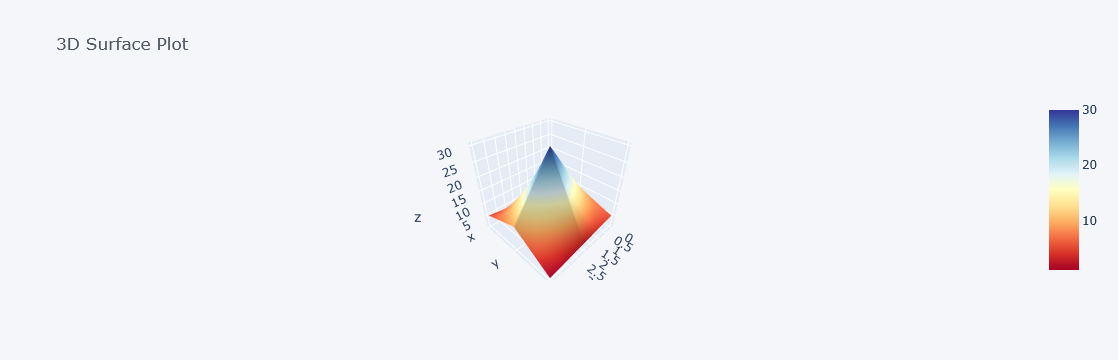

In [9]:
df3 = pd.DataFrame({
    'x': [1, 2, 3, 4, 5],
    'y': [10, 20, 30, 20, 10],
    'z': [5, 4, 3, 2, 1]
})
df3.iplot(kind='surface', colorscale='rdylbu', title='3D Surface Plot')

### Histogram

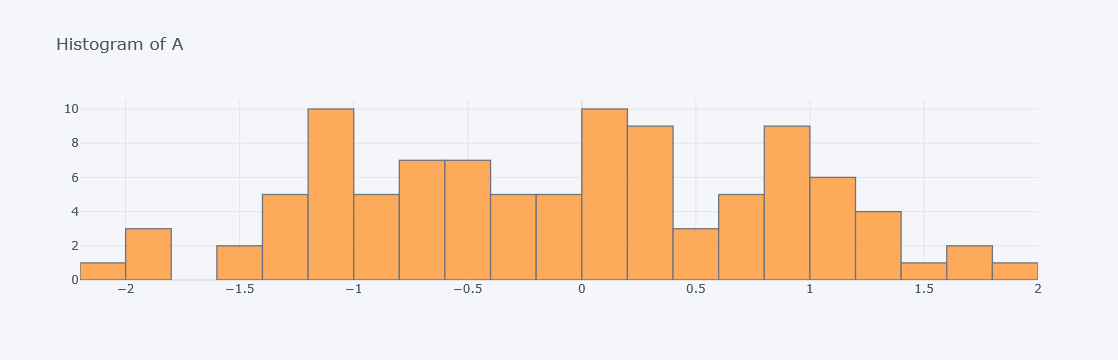

In [11]:
df['A'].iplot(kind='hist', bins=25, title='Histogram of A')

### Bubble Plot

Add size dimension to scatter plots:


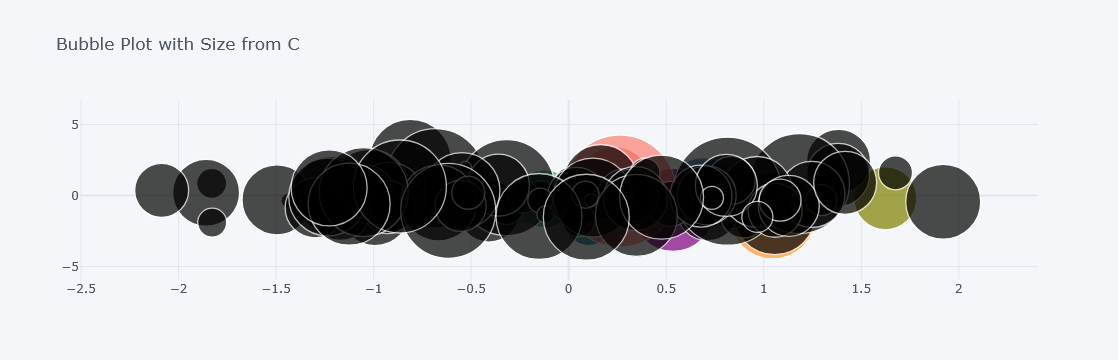

In [12]:
df.iplot(kind='bubble', x='A', y='B', size='C', title='Bubble Plot with Size from C')

### Scatter Matrix

Like seaborn’s `pairplot`, great for pairwise relationships:

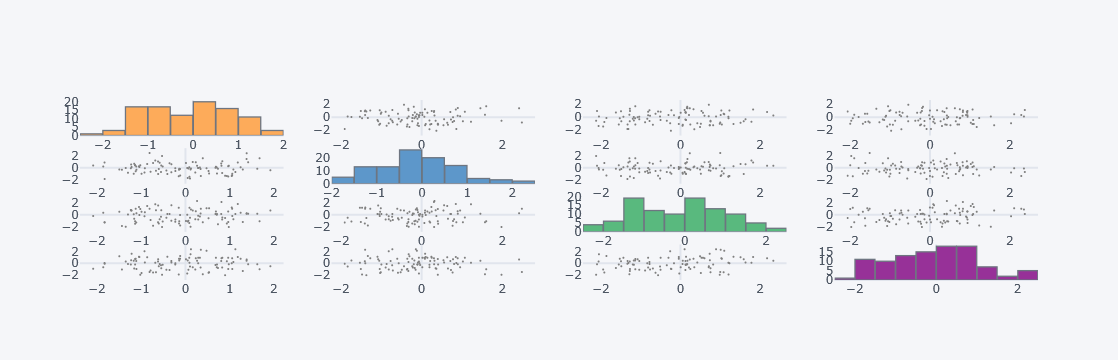

In [13]:
df.scatter_matrix()

## 🗺️ Choropleth Maps with Plotly

Visualize geographical data on **maps**. Plotly supports interactive choropleth maps for both US states and the world.

Plotly's mapping can be a bit hard to get used to at first, remember to reference the cheat sheet in the data visualization folder, or [find it online here](https://images.plot.ly/plotly-documentation/images/python_cheat_sheet.pdf).

Now we need to begin to build our data dictionary. Easiest way to do this is to use the **dict()** function of the general form:

* type = 'choropleth',
* locations = list of states
* locationmode = 'USA-states'
* colorscale= 

Either a predefined string:

    'pairs' | 'Greys' | 'Greens' | 'Bluered' | 'Hot' | 'Picnic' | 'Portland' | 'Jet' | 'RdBu' | 'Blackbody' | 'Earth' | 'Electric' | 'YIOrRd' | 'YIGnBu'

or create a [custom colorscale](https://www.geeksforgeeks.org/built-in-continuous-color-scales-in-python-plotly/)

* text= list or array of text to display per point
* z= array of values on z axis (color of state)
* colorbar = {'title':'Colorbar Title'})

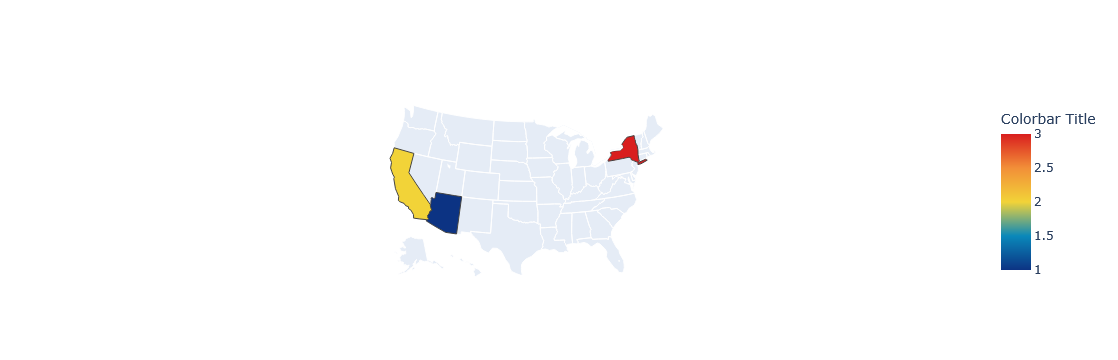

In [14]:
import plotly.graph_objs as go

data = dict(
    type='choropleth',
    locations=['AZ', 'CA', 'NY'],
    locationmode='USA-states',
    colorscale='Portland',
    text=['Arizona', 'California', 'New York'],
    z=[1.0, 2.0, 3.0],
    colorbar={'title': 'Colorbar Title'}
)

layout = dict(
    geo=dict(scope='usa')
)

fig = go.Figure(data=[data], layout=layout)
iplot(fig)

### Real Data US Map Choropleth

Now let's show an example with some real data as well as some other options we can add to the dictionaries in data and layout.

In [16]:
df = pd.read_csv('2011_US_AGRI_Exports')
df.head()

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton,text
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61,Alabama<br>Beef 34.4 Dairy 4.06<br>Fruits 25.1...
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00,Alaska<br>Beef 0.2 Dairy 0.19<br>Fruits 0.0 Ve...
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95,Arizona<br>Beef 71.3 Dairy 105.48<br>Fruits 60...
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44,Arkansas<br>Beef 53.2 Dairy 3.53<br>Fruits 6.8...
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95,California<br>Beef 228.7 Dairy 929.95<br>Frui...


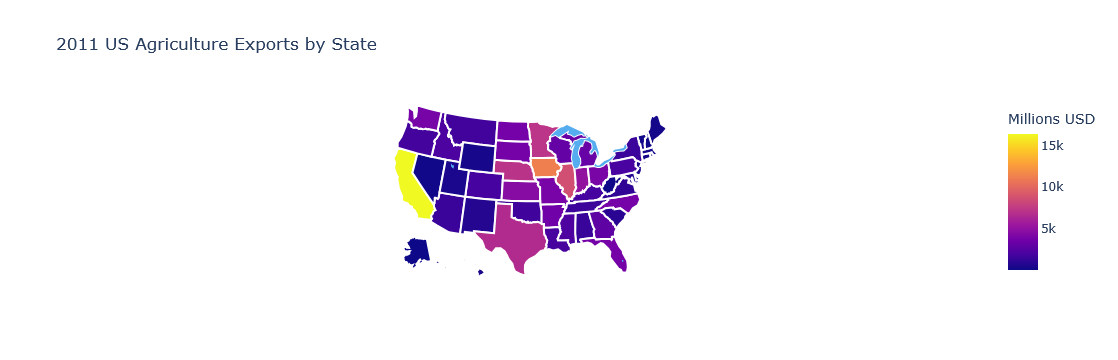

In [17]:
data = dict(
    type='choropleth',
    locations=df['code'],
    z=df['total exports'],
    locationmode='USA-states',
    text=df['text'],
    marker=dict(line=dict(color='rgb(255,255,255)', width=2)),
    colorbar={'title': 'Millions USD'}
)

layout = dict(
    title='2011 US Agriculture Exports by State',
    geo=dict(
        scope='usa',
        showlakes=True,
        lakecolor='rgb(85,173,240)'
    )
)

fig = go.Figure(data=[data], layout=layout)
iplot(fig)

# World Choropleth Map

Now let's see an example with a World Map:

In [18]:
df = pd.read_csv('2014_World_GDP')
df.head()

,COUNTRY,GDP (BILLIONS),CODE
0,Afghanistan,21.71,AFG
1,Albania,13.40,ALB
2,Algeria,227.80,DZA
3,American Samoa,0.75,ASM
4,Andorra,4.80,AND


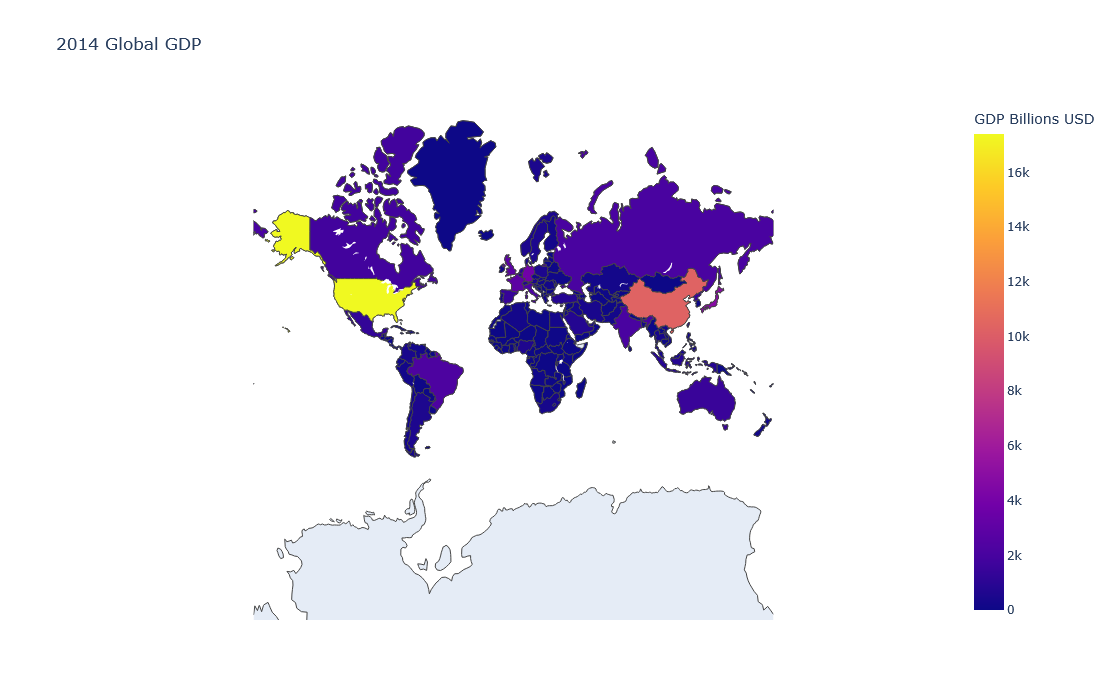

In [22]:
data = dict(
    type='choropleth',
    locations=df['CODE'],
    z=df['GDP (BILLIONS)'],
    text=df['COUNTRY'],
    colorbar={'title': 'GDP Billions USD'}
)

layout = dict(
    title='2014 Global GDP',
    geo=dict(
        showframe=False,
        projection={'type': 'mercator'} 
    ),
    
    height=700,
    width=1000
)

fig = go.Figure(data=[data], layout=layout)
iplot(fig)

# Great Job!


<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2009/Session%2009_4%20-%20Plotly%20Exercise.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>